In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import sys
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root))

from defs.vae.ae import *
from defs.vae.training_defs import *

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

spectra, fractions = load_spectral_data()
train_loader, val_loader = get_dataloaders(spectra, fractions, batch_size=1)
# unbatched_data = get_dataloader_unbatched(spectra, fractions)
num_spectra = train_loader.dataset[0][0].size(0)
print(train_loader.batch_size)
print(num_spectra)

Device: cpu
1
210


In [6]:
convolution = ConvEncoder([train_loader.batch_size, 64, 64, 64], [128, 128], c_d={'pad': 1}, num_spectra=num_spectra)
criterion = nn.MSELoss()
optimizer = optim.Adam(convolution.parameters(), lr=1e-3)

# print(convolution.encoder)
# print(convolution.decoder)

n_epochs = 10

In [7]:
train_losses = []
val_losses = []

for epoch in range(1, n_epochs+1):
    convolution.train()
    tot_loss = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        optimizer.zero_grad()
        loss_pred = criterion(convolution(xb), xb)
        loss_pred.backward()
        optimizer.step()

        tot_loss += float(loss_pred)

    train_losses.append(tot_loss / len(train_loader.dataset))

    convolution.eval()
    tot_val = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            tot_val += criterion(convolution(xb), xb).item() * xb.size(0)
    val_losses.append(tot_val / len(val_loader.dataset))

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([1, 210])) that is different to the input size (torch.Size([210])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


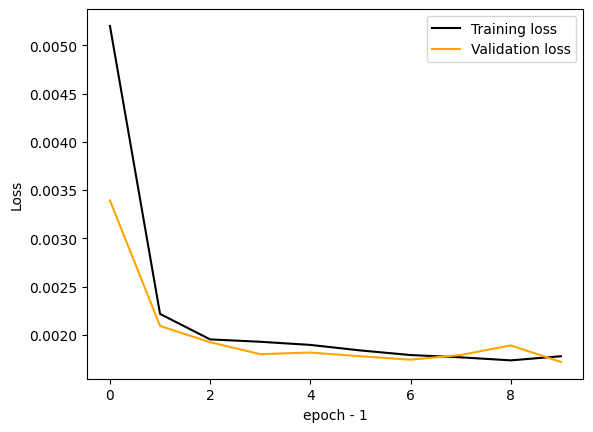

In [8]:
plt.plot(train_losses, color='black', label='Training loss')
plt.plot(val_losses, color='orange', label='Validation loss')
plt.xlabel('epoch - 1'); plt.ylabel('Loss'); plt.legend()

In [14]:
print(f'Final training MSE Loss: {train_losses[-1]:.5f}')
print(f'Final validation MSE Loss: {val_losses[-1]:.5f}')

Final training MSE Loss: 0.00178
Final validation MSE Loss: 0.00172
